<div style="background-color: #B22222; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 20px;">⚠ SUPERSEDED — Do Not Use</h2>
    <p style="color: #ffe0e0; margin: 5px 0 0 0; font-size: 13px;">
    This notebook was built on 29 July 2026 as a standalone PR-first rebuild of notebook 08's
    damage amplification pipeline, at a point when 08 was being deliberately kept as an untouched
    "before" record. Since then, notebook 08 was itself patched to load the corrected PR-first data
    (pr_df_prfirst) and has been the live, continuously-updated notebook through the domain-fix and
    Delhi-inclusion rebuild cascades. <b>08_damage_amplification.ipynb is the current, authoritative
    notebook.</b> This notebook (11) is kept only as a historical record and should not be cited,
    rerun, or used as a source of results.
    </p>
</div>

<div style="background-color: #1F3864; padding: 20px; border-radius: 5px; margin-bottom: 20px;">
    <h1 style="color: white; margin: 0; font-size: 24px;">11. Damage Amplification via f(R) Propagation (PR-First)</h1>
    <p style="color: #cce0ff; margin: 8px 0 0 0; font-size: 14px;">Rebuilds notebook 08's damage amplification analysis using the corrected PR-first PR/FAR results (notebook 07). Bias correction, capping, and f(R) propagation for Central_India, Northeast, and Western_Ghats are unchanged from notebook 08 (rainfall-only calculations, unaffected by the PR-first fix). Only Indo_Gangetic_Plain's fallback (Delta=PR) and Figure 9's PR comparison values are updated.</p>
</div>

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = '/home/ucfadod@ad.ucl.ac.uk/Documents/Dissertation/outputs/'
REGION_ORDER = ['Central_India', 'Indo_Gangetic_Plain', 'Northeast', 'Western_Ghats']

fR_params = pd.read_csv(OUTPUT_DIR + 'fR_fitted_parameters.csv')
fR_input = pd.read_csv(OUTPUT_DIR + 'fR_input_data.csv')

ant_samples = xr.open_dataset(OUTPUT_DIR + 'pr_far_windowed_samples_ant.nc')
nat_samples = xr.open_dataset(OUTPUT_DIR + 'pr_far_windowed_samples_nat.nc')

# PR-FIRST corrected results (notebook 07), replacing average-first pr_df
pr_df_prfirst = pd.read_csv(OUTPUT_DIR + 'pr_far_rolling_window_results_PRFIRST.csv')

PRESENT_DAY_WINDOW = 2005  # centred 2005, covering 1995-2014

print(fR_params)

                region         form    intercept      slope        r2  n_obs  \
0        Central_India  exponential    10.784454   0.022371  0.189091     21   
1  Indo_Gangetic_Plain       linear  4972.942961  -8.435410  0.000290     21   
2            Northeast       linear -2117.851165  15.892110  0.105389     21   
3        Western_Ghats  exponential     0.043749   0.059176  0.223488     21   

    boot_ci_5  boot_ci_95  n_boot_failed  use_fallback  
0    0.006712    0.048626              0         False  
1 -170.372802  144.967261              0          True  
2    1.043815   33.901548              0         False  
3    0.014559    0.151622             59         False  


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Part 1: Extrapolation Check</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Checks what fraction of the present-day (2005-window) MPI-GE anthropogenic Rx5day samples fall outside the range of rainfall values ERA5 actually observed -- the range f(R) was fitted and validated on. High extrapolation would mean f(R) is being asked to make predictions far beyond its calibrated range.</p>
</div>

In [2]:
FR_REGIONS = [r for r in REGION_ORDER if r != 'Indo_Gangetic_Plain']

extrap_records = []
for region in FR_REGIONS:
    obs = fR_input[fR_input.region == region]['rx5day_mm']
    obs_min, obs_max = obs.min(), obs.max()

    ant_vals = ant_samples['rx5day_ant_windowed'].sel(
        window_centre_year=PRESENT_DAY_WINDOW, region=region).values

    n_below = np.sum(ant_vals < obs_min)
    n_above = np.sum(ant_vals > obs_max)
    n_outside = n_below + n_above
    pct_outside = 100 * n_outside / len(ant_vals)

    extrap_records.append({
        'region': region,
        'ERA5_obs_min': obs_min, 'ERA5_obs_max': obs_max,
        'MPI_ant_min': ant_vals.min(), 'MPI_ant_max': ant_vals.max(),
        'n_below_range': n_below, 'n_above_range': n_above,
        'pct_outside_range': pct_outside
    })

extrap_df = pd.DataFrame(extrap_records)
print(extrap_df.to_string(index=False))

       region  ERA5_obs_min  ERA5_obs_max  MPI_ant_min  MPI_ant_max  n_below_range  n_above_range  pct_outside_range
Central_India    141.119373    227.595961    88.208368   155.926270            580              0          96.666667
    Northeast    201.850704    330.030444    99.840172   222.207611            593              0          98.833333
Western_Ghats    133.382511    201.341153    62.563768   170.029359            597              0          99.500000


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Part 2: Bias Correction (MPI vs ERA5)</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Derives a multiplicative scale factor per region from the 2000-2014 MPI/ERA5 overlap period, correcting MPI's dry bias before rainfall values are propagated through f(R). Rainfall-only calculation, unaffected by the PR-first correction.</p>
</div>

In [3]:
rx5day_ant_full = xr.open_dataset(OUTPUT_DIR + 'rx5day_ant_regional.nc')

OVERLAP_YEARS = slice(2000, 2014)

bias_records = []
for region in FR_REGIONS:
    region_idx = REGION_ORDER.index(region)

    mpi_overlap = rx5day_ant_full['rx5day_ant_regional'].isel(region=region_idx).sel(
        year=OVERLAP_YEARS).values.flatten()
    mpi_mean = np.mean(mpi_overlap)

    era5_overlap = fR_input[(fR_input.region == region) &
                             (fR_input.year >= 2000) & (fR_input.year <= 2014)]['rx5day_mm']
    era5_mean = era5_overlap.mean()

    scale_factor = era5_mean / mpi_mean

    bias_records.append({
        'region': region, 'MPI_mean_2000_2014': mpi_mean, 'ERA5_mean_2000_2014': era5_mean,
        'scale_factor': scale_factor, 'n_era5_years': len(era5_overlap)
    })

bias_df = pd.DataFrame(bias_records)
print(bias_df.to_string(index=False))

       region  MPI_mean_2000_2014  ERA5_mean_2000_2014  scale_factor  n_era5_years
Central_India          120.180919           193.080076      1.606578            15
    Northeast          142.309386           261.994835      1.841023            15
Western_Ghats           94.036232           172.942060      1.839100            15


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Part 3: Apply Bias Correction and Re-check Extrapolation</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Applies the scale factors to the present-day MPI samples and re-checks how much extrapolation beyond the ERA5-observed range remains. Rainfall-only calculation, unaffected by the PR-first correction.</p>
</div>

In [4]:
corrected_ant = {}
corrected_nat = {}

for region in FR_REGIONS:
    scale = bias_df[bias_df.region == region]['scale_factor'].values[0]

    ant_vals = ant_samples['rx5day_ant_windowed'].sel(
        window_centre_year=PRESENT_DAY_WINDOW, region=region).values
    nat_vals = nat_samples['rx5day_nat_windowed'].sel(
        window_centre_year=PRESENT_DAY_WINDOW, region=region).values

    corrected_ant[region] = ant_vals * scale
    corrected_nat[region] = nat_vals * scale

# re-check extrapolation using corrected values
recheck_records = []
for region in FR_REGIONS:
    obs = fR_input[fR_input.region == region]['rx5day_mm']
    obs_min, obs_max = obs.min(), obs.max()

    vals = corrected_ant[region]
    n_below = np.sum(vals < obs_min)
    n_above = np.sum(vals > obs_max)
    pct_outside = 100 * (n_below + n_above) / len(vals)

    recheck_records.append({
        'region': region, 'ERA5_obs_min': obs_min, 'ERA5_obs_max': obs_max,
        'corrected_MPI_ant_min': vals.min(), 'corrected_MPI_ant_max': vals.max(),
        'pct_outside_range': pct_outside
    })

recheck_df = pd.DataFrame(recheck_records)
print(recheck_df.to_string(index=False))

       region  ERA5_obs_min  ERA5_obs_max  corrected_MPI_ant_min  corrected_MPI_ant_max  pct_outside_range
Central_India    141.119373    227.595961             141.713665             250.507787           2.666667
    Northeast    201.850704    330.030444             183.808041             409.089297           6.833333
Western_Ghats    133.382511    201.341153             115.061042             312.701040          10.500000


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Part 4: Propagate Rainfall Through f(R)</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Evaluates each region's fitted f(R) curve on the bias-corrected present-day rainfall samples to compute E[D_ant], E[D_nat], and Delta = E[D_ant]/E[D_nat]. Rainfall-only calculation, unaffected by the PR-first correction.</p>
</div>

In [5]:
def evaluate_fR(region, R_values, params_df):
    row = params_df[params_df.region == region].iloc[0]
    form = row['form']
    if form == 'linear':
        return row['intercept'] + row['slope'] * R_values
    elif form == 'exponential':
        return row['intercept'] * np.exp(row['slope'] * R_values)
    elif form == 'power':
        return row['intercept'] * np.power(R_values, row['slope'])

propagation_records = []
for region in FR_REGIONS:
    D_ant = evaluate_fR(region, corrected_ant[region], fR_params)
    D_nat = evaluate_fR(region, corrected_nat[region], fR_params)

    n_neg_ant = np.sum(D_ant < 0)
    n_neg_nat = np.sum(D_nat < 0)

    E_D_ant = np.mean(D_ant)
    E_D_nat = np.mean(D_nat)
    delta = E_D_ant / E_D_nat

    propagation_records.append({
        'region': region, 'form': fR_params[fR_params.region == region]['form'].values[0],
        'E_D_ant': E_D_ant, 'E_D_nat': E_D_nat, 'delta': delta,
        'n_negative_D_ant': n_neg_ant, 'n_negative_D_nat': n_neg_nat,
        'D_ant_min': D_ant.min(), 'D_nat_min': D_nat.min()
    })

propagation_df = pd.DataFrame(propagation_records)
print(propagation_df.to_string(index=False))

       region        form      E_D_ant     E_D_nat    delta  n_negative_D_ant  n_negative_D_nat  D_ant_min  D_nat_min
Central_India exponential   859.913232  817.554791 1.051811                 0                 0 256.807786 275.715690
    Northeast      linear  2050.428435 2019.523944 1.015303                 0                 0 803.246365 953.526451
Western_Ghats exponential 12068.728579 3115.225388 3.874111                 0                 0  39.629443  22.605708


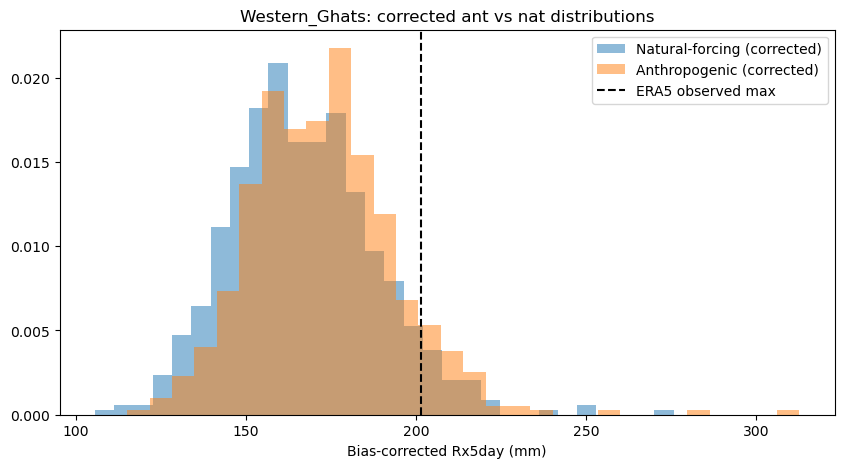

ant mean/max: 172.6914687570132 312.7010401452935
nat mean/max: 166.9517916174098 275.72427580737497


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(corrected_nat['Western_Ghats'], bins=30, alpha=0.5, label='Natural-forcing (corrected)', density=True)
ax.hist(corrected_ant['Western_Ghats'], bins=30, alpha=0.5, label='Anthropogenic (corrected)', density=True)
ax.axvline(fR_input[fR_input.region == 'Western_Ghats']['rx5day_mm'].max(),
           color='black', linestyle='--', label='ERA5 observed max')
ax.legend()
ax.set_xlabel('Bias-corrected Rx5day (mm)')
ax.set_title('Western_Ghats: corrected ant vs nat distributions')
plt.show()

print("ant mean/max:", corrected_ant['Western_Ghats'].mean(), corrected_ant['Western_Ghats'].max())
print("nat mean/max:", corrected_nat['Western_Ghats'].mean(), corrected_nat['Western_Ghats'].max())

In [7]:
D_ant_wg = evaluate_fR('Western_Ghats', corrected_ant['Western_Ghats'], fR_params)

# sort descending, look at cumulative contribution to the mean
sorted_D = np.sort(D_ant_wg)[::-1]
top_5_share = sorted_D[:5].sum() / sorted_D.sum() * 100
top_10_share = sorted_D[:10].sum() / sorted_D.sum() * 100

print(f"Top 5 samples (of 600) contribute {top_5_share:.1f}% of E[D_ant]")
print(f"Top 10 samples (of 600) contribute {top_10_share:.1f}% of E[D_ant]")
print(f"Largest 5 D values: {sorted_D[:5]}")

Top 5 samples (of 600) contribute 81.3% of E[D_ant]
Top 10 samples (of 600) contribute 83.1% of E[D_ant]
Largest 5 D values: [4756993.43650434  879029.39046028  160377.64129251   53488.35122827
   38939.91953735]


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Part 4b: Cap Extrapolated Samples Before Propagation</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Caps bias-corrected rainfall samples at the ERA5-observed min/max before evaluating f(R), preventing a small number of extreme out-of-range samples from dominating E[D]. Rainfall-only calculation, unaffected by the PR-first correction.</p>
</div>

In [8]:
def cap_to_observed_range(values, region):
    obs = fR_input[fR_input.region == region]['rx5day_mm']
    return np.clip(values, obs.min(), obs.max())

capped_ant = {r: cap_to_observed_range(corrected_ant[r], r) for r in FR_REGIONS}
capped_nat = {r: cap_to_observed_range(corrected_nat[r], r) for r in FR_REGIONS}

capped_records = []
for region in FR_REGIONS:
    D_ant = evaluate_fR(region, capped_ant[region], fR_params)
    D_nat = evaluate_fR(region, capped_nat[region], fR_params)

    E_D_ant, E_D_nat = np.mean(D_ant), np.mean(D_nat)
    delta = E_D_ant / E_D_nat

    n_capped_ant = np.sum(corrected_ant[region] != capped_ant[region])
    n_capped_nat = np.sum(corrected_nat[region] != capped_nat[region])

    capped_records.append({
        'region': region, 'E_D_ant': E_D_ant, 'E_D_nat': E_D_nat, 'delta': delta,
        'pct_capped_ant': 100*n_capped_ant/600, 'pct_capped_nat': 100*n_capped_nat/600
    })

capped_df = pd.DataFrame(capped_records)
print(capped_df.to_string(index=False))

       region     E_D_ant     E_D_nat    delta  pct_capped_ant  pct_capped_nat
Central_India  851.840136  810.389826 1.051149        2.666667        1.500000
    Northeast 2028.643201 2015.271344 1.006635        6.833333        4.166667
Western_Ghats 1891.319132 1523.636866 1.241319       10.500000       10.333333


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Part 5: Combine All Four Regions (PR-First IGP Fallback)</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Combines the three f(R)-derived regions with Indo_Gangetic_Plain's fallback, where Delta = PR. This now uses the corrected PR-first present-day PR value from notebook 07, rather than the original average-first value.</p>
</div>

In [9]:
igp_pr = pr_df_prfirst[(pr_df_prfirst.region == 'Indo_Gangetic_Plain') &
                        (pr_df_prfirst.year == PRESENT_DAY_WINDOW)].iloc[0]

igp_row = pd.DataFrame([{
    'region': 'Indo_Gangetic_Plain',
    'E_D_ant': np.nan,
    'E_D_nat': np.nan,
    'delta': igp_pr['PR'],
    'pct_capped_ant': np.nan,
    'pct_capped_nat': np.nan
}])

delta_results = pd.concat([capped_df, igp_row], ignore_index=True)
delta_results['method'] = delta_results['region'].apply(
    lambda r: 'FAR x AAL fallback (Delta=PR, PR-first)' if r == 'Indo_Gangetic_Plain' else 'f(R) propagation'
)

delta_results['region'] = pd.Categorical(delta_results['region'], categories=REGION_ORDER, ordered=True)
delta_results = delta_results.sort_values('region').reset_index(drop=True)

print(delta_results.to_string(index=False))

             region     E_D_ant     E_D_nat    delta  pct_capped_ant  pct_capped_nat                                  method
      Central_India  851.840136  810.389826 1.051149        2.666667        1.500000                        f(R) propagation
Indo_Gangetic_Plain         NaN         NaN 1.237283             NaN             NaN FAR x AAL fallback (Delta=PR, PR-first)
          Northeast 2028.643201 2015.271344 1.006635        6.833333        4.166667                        f(R) propagation
      Western_Ghats 1891.319132 1523.636866 1.241319       10.500000       10.333333                        f(R) propagation


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Part 6: Bootstrap Confidence Intervals for Delta</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Member-level bootstrap for Central_India, Northeast, and Western_Ghats (rainfall-only, unchanged from notebook 08). Indo_Gangetic_Plain reuses its PR-first bootstrap CI from notebook 07.</p>
</div>

In [10]:
rx5day_ant = xr.open_dataset(OUTPUT_DIR + 'rx5day_ant_regional.nc')
rx5day_nat = xr.open_dataset(OUTPUT_DIR + 'rx5day_nat_regional.nc')

In [11]:
N_BOOT = 1000
np.random.seed(42)

def get_member_window(ds, varname, region_idx, t):
    return ds[varname].isel(region=region_idx).sel(
        year=slice(t - 10, t + 9)).values  # shape (30, 20)

bootstrap_delta = {region: np.full(N_BOOT, np.nan) for region in FR_REGIONS}

for region in FR_REGIONS:
    region_idx = REGION_ORDER.index(region)
    scale = bias_df[bias_df.region == region]['scale_factor'].values[0]
    obs = fR_input[fR_input.region == region]['rx5day_mm']
    obs_min, obs_max = obs.min(), obs.max()

    ant_raw = get_member_window(rx5day_ant, 'rx5day_ant_regional', region_idx, PRESENT_DAY_WINDOW)
    nat_raw = get_member_window(rx5day_nat, 'rx5day_nat_regional', region_idx, PRESENT_DAY_WINDOW)
    n_members = ant_raw.shape[0]

    for i in range(N_BOOT):
        idx = np.random.choice(n_members, size=n_members, replace=True)

        ant_boot = (ant_raw[idx] * scale).flatten()
        nat_boot = (nat_raw[idx] * scale).flatten()

        ant_boot_capped = np.clip(ant_boot, obs_min, obs_max)
        nat_boot_capped = np.clip(nat_boot, obs_min, obs_max)

        D_ant = evaluate_fR(region, ant_boot_capped, fR_params)
        D_nat = evaluate_fR(region, nat_boot_capped, fR_params)

        bootstrap_delta[region][i] = np.mean(D_ant) / np.mean(D_nat)

delta_ci_records = []
for region in FR_REGIONS:
    lo, hi = np.nanpercentile(bootstrap_delta[region], [5, 95])
    delta_ci_records.append({'region': region, 'delta_ci_5': lo, 'delta_ci_95': hi})

# IGP reuses its PR-first bootstrap from notebook 07
delta_ci_records.append({
    'region': 'Indo_Gangetic_Plain',
    'delta_ci_5': igp_pr['PR_ci_5'], 'delta_ci_95': igp_pr['PR_ci_95']
})

delta_ci_df = pd.DataFrame(delta_ci_records)
delta_results = delta_results.merge(delta_ci_df, on='region')
print(delta_results[['region', 'delta', 'delta_ci_5', 'delta_ci_95', 'method']].to_string(index=False))

             region    delta  delta_ci_5  delta_ci_95                                  method
      Central_India 1.051149    1.021344     1.081441                        f(R) propagation
Indo_Gangetic_Plain 1.237283    1.145637     1.374450 FAR x AAL fallback (Delta=PR, PR-first)
          Northeast 1.006635    0.984720     1.030905                        f(R) propagation
      Western_Ghats 1.241319    1.147327     1.341149                        f(R) propagation


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Part 7: Figure 9 - Regional Damage Amplification Ratios (PR-First)</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">PR values now come from the PR-first present-day results (notebook 07), replacing the original average-first PR bars.</p>
</div>

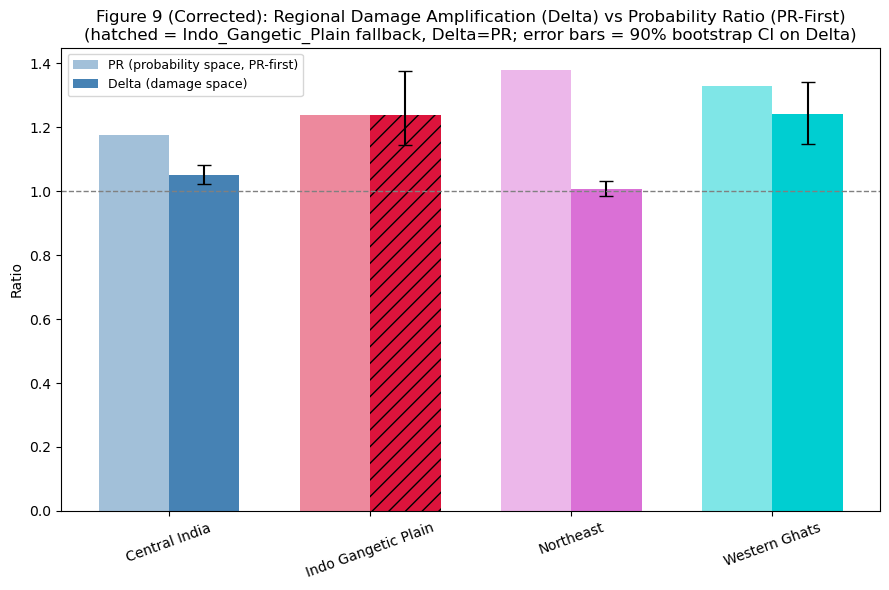

In [12]:
region_colors = {
    'Central_India': 'steelblue',
    'Indo_Gangetic_Plain': 'crimson',
    'Northeast': 'orchid',
    'Western_Ghats': 'darkturquoise'
}

# Pull PR-first present-day PR per region (matches delta_results order)
pr_present_df = pr_df_prfirst[pr_df_prfirst.year == PRESENT_DAY_WINDOW][['region', 'PR']].rename(
    columns={'PR': 'PR_present'}
)
delta_results = delta_results.merge(pr_present_df, on='region')

fig, ax = plt.subplots(figsize=(9, 6))

width = 0.35
x = np.arange(len(REGION_ORDER))
pr_vals = delta_results.set_index('region').loc[REGION_ORDER, 'PR_present']
deltas = delta_results.set_index('region').loc[REGION_ORDER, 'delta']
ci_lo = delta_results.set_index('region').loc[REGION_ORDER, 'delta_ci_5']
ci_hi = delta_results.set_index('region').loc[REGION_ORDER, 'delta_ci_95']
err = [deltas - ci_lo, ci_hi - deltas]
colors = [region_colors[r] for r in REGION_ORDER]
hatches = ['' if r != 'Indo_Gangetic_Plain' else '//' for r in REGION_ORDER]

bars_pr = ax.bar(x - width/2, pr_vals, width, label='PR (probability space, PR-first)',
                  color=colors, alpha=0.5)
bars_delta = ax.bar(x + width/2, deltas, width, yerr=err, capsize=5,
                     label='Delta (damage space)', color=colors, alpha=1.0)
for bar_delta, hatch in zip(bars_delta, hatches):
    bar_delta.set_hatch(hatch)

ax.axhline(1, color='grey', linestyle='--', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels([r.replace('_', ' ') for r in REGION_ORDER], rotation=20)
ax.set_ylabel('Ratio')
ax.set_title('Figure 9 (Corrected): Regional Damage Amplification (Delta) vs Probability Ratio (PR-First)\n(hatched = Indo_Gangetic_Plain fallback, Delta=PR; error bars = 90% bootstrap CI on Delta)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'figure9_damage_amplification_PRFIRST.png', dpi=150, bbox_inches='tight')
plt.show()

<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Part 8: Save Delta Results</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Saves the corrected PR-first damage amplification results to a new file, leaving notebook 08's original average-first output untouched.</p>
</div>

In [13]:
delta_results['delta_rank'] = delta_results['delta'].rank(ascending=False).astype(int)
delta_results['PR_rank'] = delta_results['PR_present'].rank(ascending=False).astype(int)

delta_results_out = delta_results[['region', 'method', 'PR_present', 'delta',
                                     'delta_ci_5', 'delta_ci_95',
                                     'pct_capped_ant', 'pct_capped_nat',
                                     'delta_rank', 'PR_rank']]

delta_results_out.to_csv(OUTPUT_DIR + 'damage_amplification_results_PRFIRST.csv', index=False)
print(f"Saved {len(delta_results_out)} rows")
print(delta_results_out)

Saved 4 rows
                region                                   method  PR_present  \
0        Central_India                         f(R) propagation    1.175537   
1  Indo_Gangetic_Plain  FAR x AAL fallback (Delta=PR, PR-first)    1.237283   
2            Northeast                         f(R) propagation    1.379500   
3        Western_Ghats                         f(R) propagation    1.328223   

      delta  delta_ci_5  delta_ci_95  pct_capped_ant  pct_capped_nat  \
0  1.051149    1.021344     1.081441        2.666667        1.500000   
1  1.237283    1.145637     1.374450             NaN             NaN   
2  1.006635    0.984720     1.030905        6.833333        4.166667   
3  1.241319    1.147327     1.341149       10.500000       10.333333   

   delta_rank  PR_rank  
0           3        4  
1           2        3  
2           4        1  
3           1        2  


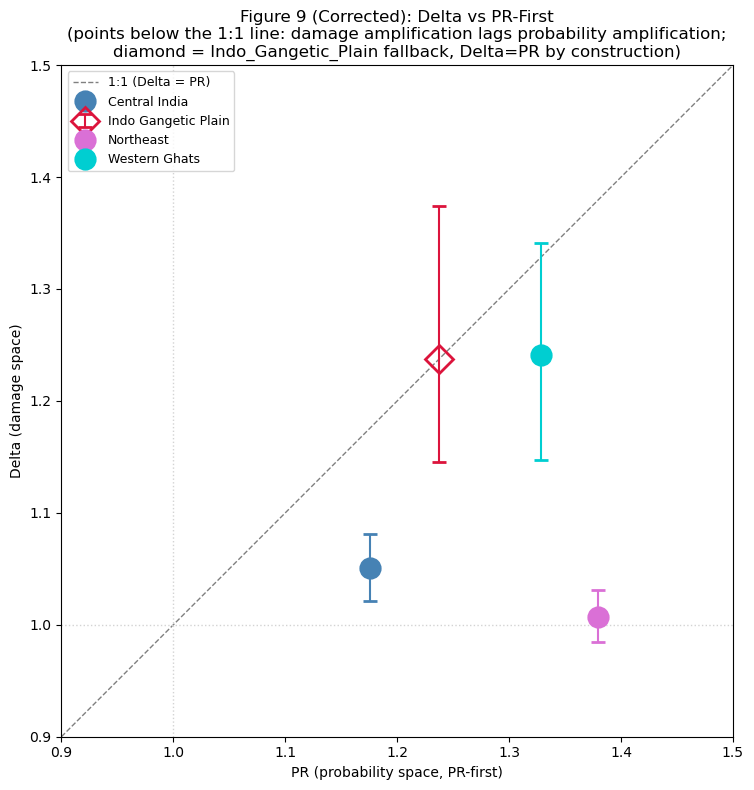

In [14]:
fig, ax = plt.subplots(figsize=(8, 8))

for region in REGION_ORDER:
    row = delta_results[delta_results.region == region].iloc[0]
    pr_val = row['PR_present']
    delta_val = row['delta']
    err_lo = delta_val - row['delta_ci_5']
    err_hi = row['delta_ci_95'] - delta_val

    marker = 'D' if region == 'Indo_Gangetic_Plain' else 'o'  # diamond for IGP fallback
    facecolor = 'none' if region == 'Indo_Gangetic_Plain' else region_colors[region]
    edgecolor = region_colors[region]

    ax.errorbar(pr_val, delta_val, yerr=[[err_lo], [err_hi]],
                fmt=marker, markersize=14, markerfacecolor=facecolor,
                markeredgecolor=edgecolor, markeredgewidth=2,
                ecolor=edgecolor, capsize=5, elinewidth=1.5, label=region.replace('_', ' '))

# 1:1 reference line
lims = [0.9, 1.5]
ax.plot(lims, lims, color='grey', linestyle='--', linewidth=1, label='1:1 (Delta = PR)', zorder=0)
ax.axhline(1, color='lightgrey', linestyle=':', linewidth=1, zorder=0)
ax.axvline(1, color='lightgrey', linestyle=':', linewidth=1, zorder=0)

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('PR (probability space, PR-first)')
ax.set_ylabel('Delta (damage space)')
ax.set_title('Figure 9 (Corrected): Delta vs PR-First\n(points below the 1:1 line: damage amplification lags probability amplification;\ndiamond = Indo_Gangetic_Plain fallback, Delta=PR by construction)')
ax.legend(fontsize=9, loc='upper left')
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'figure9_damage_amplification_PRFIRST_scatter.png', dpi=150, bbox_inches='tight')
plt.show()